# 14_geo_unet_train_v1.ipynb

U-Net с **geometry-conditioned branch** вместо bilinear-лифта.

## Чем отличается от 13_unet_train_v1
Тот ноутбук делал `(2, 16, 256) → (2, 192, 192)` через bilinear interpolation —
быстро, но геометрически бессмысленно: соседство по индексу приёмника подменяется
гладкой 2D-картинкой, не имеющей отношения к физическим позициям датчиков. Это
и причина того, что в `25_sensor_geometry_robustness` все наивные модели (DeepONet,
FNO, plain U-Net) разваливаются при `receiver_shift=4`.

Здесь bilinear-lift заменён на четыре стадии:

1. **Token construction.** Каждая пара (источник `s`, приёмник `r`) превращается в
   токен из 8 чисел: `(Re, Im, src_y, src_x, rcv_y, rcv_x, ray_y, ray_x)`. Все
   координаты в `[-1, 1]`. Это `S × R = 4096` токенов на сэмпл.
2. **Per-token MLP.** Один общий MLP `8 → 64 → 64 → 32` обрабатывает каждый токен
   независимо. Получается `(S, R, 32)` embeddings.
3. **Geometry-aware lift.** Embeddings суммируются по источникам и
   `scatter_add_`-ом раскладываются в физические пиксельные позиции приёмников
   на пустой сетке `(32, 192, 192)`. Никакой bilinear-интерполяции.
4. **Spreader.** Два conv-слоя с ядром 7×7 «размазывают» sparse-вложение, чтобы
   информация дошла до соседних пикселей до первого downsampling в U-Net.

Дальше — **тот же U-Net body**, что в `13_unet_train_v1` (4 уровня, base_ch=32, GN,
bilinear-up в Up-блоках, линейный выход).

## Свойство, которого нет у предыдущих моделей
Архитектура **по построению инвариантна** к перенумерации приёмников и источников —
если поменять местами столбцы в `M` и одновременно тот же permutation применить к
координатам, выход модели **точно** не изменится (модулу численного шума
суммирования с плавающей точкой). Sanity-тест на это включён ниже в разделе 4.

Это означает, что **circular shift** приёмников (главная проблема `25_*`) по идее
вообще не должен ничего ломать — и для бакалаврского эксперимента это будет самое
наглядное доказательство ценности geometry-conditioning.

## 1. Импорты и конфиг

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ.pop("LD_LIBRARY_PATH", None)

'/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/local/cuda/lib64'

In [2]:
from pathlib import Path
import json
import math
import random
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))

torch: 2.11.0+cu130
cuda available: True
device name: NVIDIA GeForce RTX 5090


In [3]:
CFG = {
    "dataset_root": "/workspace/usct_dataset_v2",
    "run_name": "geo_unet_v1",
    "batch_size": 8,
    "epochs": 200,
    "patience": 30,
    "lr": 1e-3,
    "min_lr": 1e-5,
    "weight_decay": 1e-6,
    "num_workers": 0,
    "mask_half_width": 2,
    "use_residual": True,

    # Geometry branch hyperparams
    "token_dim": 8,
    "branch_hidden": 64,
    "embed_dim": 32,
    "source_aggregation": "sum",   # "sum" or "mean"

    # Spreader hyperparams
    "spreader_kernel": 7,
    "spreader_layers": 2,

    # U-Net body
    "unet_base_ch": 32,
    "unet_use_bilinear_up": True,

    # LR schedule
    "scheduler_factor": 0.5,
    "scheduler_patience": 8,

    # Optional debug
    "overfit_debug_enabled": True,
    "overfit_subset_size": 8,
    "overfit_epochs": 200,
    "overfit_lr": 1e-3,
}
CFG

{'dataset_root': '/workspace/usct_dataset_v2',
 'run_name': 'geo_unet_v1',
 'batch_size': 8,
 'epochs': 200,
 'patience': 30,
 'lr': 0.001,
 'min_lr': 1e-05,
 'weight_decay': 1e-06,
 'num_workers': 0,
 'mask_half_width': 2,
 'use_residual': True,
 'token_dim': 8,
 'branch_hidden': 64,
 'embed_dim': 32,
 'source_aggregation': 'sum',
 'spreader_kernel': 7,
 'spreader_layers': 2,
 'unet_base_ch': 32,
 'unet_use_bilinear_up': True,
 'scheduler_factor': 0.5,
 'scheduler_patience': 8,
 'overfit_debug_enabled': True,
 'overfit_subset_size': 8,
 'overfit_epochs': 200,
 'overfit_lr': 0.001}

In [4]:
OUT_ROOT = Path(CFG["dataset_root"])
TRAIN_DIR = OUT_ROOT / "train"
VAL_DIR = OUT_ROOT / "val"
TEST_DIR = OUT_ROOT / "test"

assert TRAIN_DIR.exists(), TRAIN_DIR
assert VAL_DIR.exists(), VAL_DIR
assert TEST_DIR.exists(), TEST_DIR

train_files = sorted(TRAIN_DIR.glob("*.npz"))
val_files = sorted(VAL_DIR.glob("*.npz"))
test_files = sorted(TEST_DIR.glob("*.npz"))

print("train:", len(train_files))
print("val:", len(val_files))
print("test:", len(test_files))
assert len(train_files) > 0 and len(val_files) > 0 and len(test_files) > 0

train: 6200
val: 1000
test: 800


In [5]:
sample0 = np.load(train_files[0])

S, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])

receiver_y = np.array(sample0["receiver_y"].astype(np.int32))
receiver_x = np.array(sample0["receiver_x"].astype(np.int32))
source_ring_idx_full = np.array(sample0["source_ring_idx"].astype(np.int32))

all_c_values = []
for p in train_files:
    c = np.load(p)["c"].astype(np.float32)
    all_c_values.append(c)
all_c_values = np.stack(all_c_values, axis=0)

stats = {
    "c_min": float(all_c_values.min()),
    "c_max": float(all_c_values.max()),
}
print("S, R:", S, R)
print("H, W:", H, W)
print("dx:", dx)
print("freq_hz:", freq_hz)
print("stats:", stats)

S, R: 16 256
H, W: 192 192
dx: (np.float32(0.00075), np.float32(0.00075))
freq_hz: 500000.0
stats: {'c_min': 1404.1473388671875, 'c_max': 1598.34423828125}


## 2. `M_hom` через j-Wave

Точная копия блока из `13_unet_train_v1`/`16_fno_train`/`12_deeponet_train_v2`,
чтобы residual был побитово идентичный во всех ноутбуках.

In [6]:
import jax
import jax.numpy as jnp
from jax import jit

from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

print("jax version:", jax.__version__)
print("jax devices:", jax.devices())

jax version: 0.4.38
jax devices: [CudaDevice(id=0)]


In [7]:
domain = Domain((H, W), dx)
omega = 2 * np.pi * freq_hz

def gaussian_source(H, W, y0, x0, sigma=1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    g = g / g.sum()
    return g.astype(np.float32)

full_source_fields = []
for ridx in source_ring_idx_full:
    y0 = int(receiver_y[ridx])
    x0 = int(receiver_x[ridx])
    src_np = gaussian_source(H, W, y0, x0, sigma=1.8)
    full_source_fields.append(jnp.array(src_np, dtype=jnp.complex64))
full_source_fields = tuple(full_source_fields)

def make_medium(c_map):
    sound_speed = FourierSeries(jnp.expand_dims(jnp.array(c_map), -1), domain)
    medium = Medium(domain=domain, sound_speed=sound_speed, density=1000.0, pml_size=16)
    return medium

def forward_measurements_full(c_map):
    medium = make_medium(c_map)
    ms = []
    for i in range(len(full_source_fields)):
        src = FourierSeries(jnp.expand_dims(full_source_fields[i], -1), domain)
        field = helmholtz_solver(medium, omega, src * omega)
        u = field.params[..., 0]
        ms.append(u[receiver_y, receiver_x])
    return jnp.stack(ms, axis=0)

forward_measurements_full_jit = jit(forward_measurements_full)

/tmp/ipykernel_2471/1657452440.py:1: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


In [8]:
c_hom = jnp.full((H, W), 1500.0, dtype=jnp.float32)

t0 = time.time()
M_hom_complex = forward_measurements_full_jit(c_hom)
M_hom_complex.block_until_ready()
t1 = time.time()

M_hom_complex = np.array(M_hom_complex)

print("M_hom_complex:", M_hom_complex.shape, M_hom_complex.dtype)
print("time:", t1 - t0, "sec")

M_hom_complex: (16, 256) complex64
time: 9.897425651550293 sec


## 3. Dataset

Возвращает `(x, c, src_norm, rcv_norm, rcv_pixel, meta)`:
- `x` — тот же `(2, 16, 256)` residual measurement, что и в 13/16.
- `c` — нормированная в `[-1, 1]` карта скорости.
- `src_norm`: `(S, 2)`, координаты источников в `[-1, 1]`.
- `rcv_norm`: `(R, 2)`, координаты приёмников в `[-1, 1]`.
- `rcv_pixel`: `(R, 2)`, целочисленные пиксельные позиции приёмников (для scatter).

Все три геометрические тензоры читаются из тех же `receiver_y/x` и `source_ring_idx`,
которые `04_generate_dataset_v2` сохраняет в каждом npz. Перегенерация не требуется.

In [9]:
def mask_self_receivers(M, source_ring_idx, half_width=2):
    M = M.copy()
    S_local, R_local = M.shape
    for s in range(S_local):
        ridx = int(source_ring_idx[s])
        for delta in range(-half_width, half_width + 1):
            rr = (ridx + delta) % R_local
            M[s, rr] = 0.0 + 0.0j
    return M

class USCTGeoDataset(Dataset):
    def __init__(self, paths, c_min, c_max, M_hom_complex, H, W,
                 use_residual=True, mask_half_width=2):
        self.paths = list(paths)
        self.c_min = float(c_min)
        self.c_max = float(c_max)
        self.c_range = max(self.c_max - self.c_min, 1e-8)
        self.M_hom_complex = M_hom_complex
        self.use_residual = bool(use_residual)
        self.mask_half_width = int(mask_half_width)
        self.H = int(H)
        self.W = int(W)

    def __len__(self):
        return len(self.paths)

    def normalize_target(self, c):
        return 2.0 * (c - self.c_min) / self.c_range - 1.0

    def denormalize_target(self, c_norm):
        return ((c_norm + 1.0) * 0.5) * self.c_range + self.c_min

    def __getitem__(self, idx):
        d = np.load(self.paths[idx])

        x_raw = d["x"].astype(np.float32)
        c_map = d["c"].astype(np.float32)
        source_ring_idx = d["source_ring_idx"].astype(np.int64)
        rcv_y = d["receiver_y"].astype(np.int64)
        rcv_x = d["receiver_x"].astype(np.int64)

        # 1) измерение + residual + маска ближних
        M = x_raw[0] + 1j * x_raw[1]
        if self.use_residual:
            M = M - self.M_hom_complex
        if self.mask_half_width > 0:
            M = mask_self_receivers(M, source_ring_idx, half_width=self.mask_half_width)

        x_tensor = np.stack([M.real, M.imag], axis=0).astype(np.float32)
        x_scale = float(np.percentile(np.abs(x_tensor), 99.5))
        if x_scale < 1e-8:
            x_scale = 1.0
        x_tensor = x_tensor / x_scale

        # 2) target
        c_norm = self.normalize_target(c_map).astype(np.float32)

        # 3) геометрия
        src_y_pix = rcv_y[source_ring_idx]   # (S,) — позиции источников в пикселях
        src_x_pix = rcv_x[source_ring_idx]

        # пиксельные позиции приёмников (для scatter)
        rcv_pixel = np.stack([rcv_y, rcv_x], axis=-1).astype(np.int64)        # (R, 2)

        # нормированные координаты для подачи в branch MLP
        rcv_norm = np.stack([
            rcv_y.astype(np.float32) / max(self.H - 1, 1) * 2 - 1,
            rcv_x.astype(np.float32) / max(self.W - 1, 1) * 2 - 1,
        ], axis=-1).astype(np.float32)                                         # (R, 2)
        src_norm = np.stack([
            src_y_pix.astype(np.float32) / max(self.H - 1, 1) * 2 - 1,
            src_x_pix.astype(np.float32) / max(self.W - 1, 1) * 2 - 1,
        ], axis=-1).astype(np.float32)                                         # (S, 2)

        return (
            torch.from_numpy(x_tensor),                  # (2, S, R)
            torch.from_numpy(c_norm).unsqueeze(0),       # (1, H, W)
            torch.from_numpy(src_norm),                  # (S, 2)
            torch.from_numpy(rcv_norm),                  # (R, 2)
            torch.from_numpy(rcv_pixel),                 # (R, 2)
            {"path": str(self.paths[idx]), "x_scale": x_scale},
        )

In [10]:
ds_train = USCTGeoDataset(
    train_files, stats["c_min"], stats["c_max"],
    M_hom_complex=M_hom_complex, H=H, W=W,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)
ds_val = USCTGeoDataset(
    val_files, stats["c_min"], stats["c_max"],
    M_hom_complex=M_hom_complex, H=H, W=W,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)
ds_test = USCTGeoDataset(
    test_files, stats["c_min"], stats["c_max"],
    M_hom_complex=M_hom_complex, H=H, W=W,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)

x0, c0, src0, rcv0, rcvp0, meta0 = ds_train[0]
print("x:        ", x0.shape, x0.dtype)
print("c:        ", c0.shape, c0.dtype, float(c0.min()), float(c0.max()))
print("src_norm: ", src0.shape, src0.dtype, "range:", float(src0.min()), float(src0.max()))
print("rcv_norm: ", rcv0.shape, rcv0.dtype, "range:", float(rcv0.min()), float(rcv0.max()))
print("rcv_pixel:", rcvp0.shape, rcvp0.dtype, "range:", int(rcvp0.min()), int(rcvp0.max()))
print(meta0)

x:         torch.Size([2, 16, 256]) torch.float32
c:         torch.Size([1, 192, 192]) torch.float32 -0.7392016053199768 0.5010437965393066
src_norm:  torch.Size([16, 2]) torch.float32 range: -0.7591623067855835 0.7591623067855835
rcv_norm:  torch.Size([256, 2]) torch.float32 range: -0.7591623067855835 0.7591623067855835
rcv_pixel: torch.Size([256, 2]) torch.int64 range: 23 168
{'path': '/workspace/usct_dataset_v2/train/sample_00000.npz', 'x_scale': 5201.529296875}


## 4. Архитектура

### 4.1 GeometryConditionedBranch

Per-token MLP: для каждой пары `(s, r)` принимает 8-мерный токен и выдаёт
`embed_dim`-мерный embedding. MLP применяется одинаково ко всем `S × R` токенам —
это и обеспечивает геометрическую инвариантность (никакой связи с конкретным
индексом массива).

In [11]:
class GeometryConditionedBranch(nn.Module):
    """Per-token MLP: (Re, Im, src_xy, rcv_xy, ray_xy) -> embedding."""

    def __init__(self, token_dim: int = 8, hidden_dim: int = 64, embed_dim: int = 32):
        super().__init__()
        self.embed_dim = int(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(token_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embed_dim),
        )

    def forward(self, x_residual, src_norm, rcv_norm):
        """
        x_residual: (B, 2, S, R) — Re/Im residual measurement
        src_norm:   (B, S, 2)    — source coords in [-1, 1]
        rcv_norm:   (B, R, 2)    — receiver coords in [-1, 1]
        Returns:    (B, S, R, embed_dim)
        """
        B, _, S, R = x_residual.shape
        # broadcast coords: (B, S, R, 2)
        src = src_norm.unsqueeze(2).expand(B, S, R, 2)
        rcv = rcv_norm.unsqueeze(1).expand(B, S, R, 2)
        ray = rcv - src
        # measurements: (B, 2, S, R) -> (B, S, R, 2)
        meas = x_residual.permute(0, 2, 3, 1).contiguous()
        # token: (B, S, R, 8)
        tokens = torch.cat([meas, src, rcv, ray], dim=-1)
        # per-token MLP -> (B, S, R, embed_dim)
        return self.mlp(tokens)

### 4.2 GeometryAwareLift

Делает две вещи:
1. Аггрегирует embeddings по источникам: `(B, S, R, C) → (B, R, C)` через `sum`
   (или `mean`, переключаемо). Сумма set-инвариантна по источникам, и информация о
   конкретных позициях источников не теряется — она зашита в embeddings ещё на
   стадии branch MLP через `src_norm`.
2. Кладёт результат на сетку `(C, H, W)` через `scatter_add_` в физические
   пиксельные позиции приёмников `rcv_pixel`. Там, где приёмников нет — нули.

Никакой bilinear-интерполяции, никакого «угадывания» формы выходного тензора по
форме входного.

In [12]:
class GeometryAwareLift(nn.Module):
    """Sparse scatter of token embeddings onto an (H, W) grid at receiver pixels."""

    def __init__(self, embed_dim: int, H: int, W: int, source_aggregation: str = "sum"):
        super().__init__()
        assert source_aggregation in ("sum", "mean")
        self.embed_dim = int(embed_dim)
        self.H = int(H)
        self.W = int(W)
        self.source_aggregation = source_aggregation

    def forward(self, embeddings, rcv_pixel):
        """
        embeddings: (B, S, R, C)
        rcv_pixel:  (B, R, 2) long, in pixel units (y, x)
        Returns:    (B, C, H, W)
        """
        B, S, R, C = embeddings.shape

        # 1) aggregate over sources -> (B, R, C)
        if self.source_aggregation == "sum":
            agg = embeddings.sum(dim=1)
        else:
            agg = embeddings.mean(dim=1)

        # 2) flat scatter: place agg[b, r, :] at pixel (rcv_y[b, r], rcv_x[b, r])
        rcv_y = rcv_pixel[..., 0].long()                       # (B, R)
        rcv_x = rcv_pixel[..., 1].long()
        flat_idx = (rcv_y * self.W + rcv_x).unsqueeze(1).expand(B, C, R)  # (B, C, R)
        agg_t = agg.permute(0, 2, 1).contiguous()              # (B, C, R)

        feat_flat = torch.zeros(B, C, self.H * self.W,
                        device=embeddings.device, dtype=agg_t.dtype)

        feat_flat.scatter_add_(2, flat_idx, agg_t)
        return feat_flat.view(B, C, self.H, self.W)

### 4.3 Spreader

После `scatter_add_` ненули стоят только в ~256 пикселях из 36864. Стандартная
3×3 свёртка U-Net видит лишь 8 ближайших соседей, и информация будет дрейфовать
очень медленно. Два слоя 7×7 conv сразу даёт receptive field ≈ 13×13 — в нём
заведомо лежат ~5–10 соседних приёмников по кольцу, и информация перемешивается
до первого downsampling.

In [13]:
def _gn(num_channels: int) -> nn.GroupNorm:
    g = 1
    for cand in (8, 4, 2):
        if num_channels % cand == 0:
            g = cand
            break
    return nn.GroupNorm(g, num_channels)


class Spreader(nn.Module):
    """A few large-kernel conv layers to spread sparsely-deposited features."""

    def __init__(self, channels: int, kernel: int = 7, num_layers: int = 2):
        super().__init__()
        layers = []
        for _ in range(num_layers):
            layers += [
                nn.Conv2d(channels, channels, kernel_size=kernel, padding=kernel // 2),
                _gn(channels),
                nn.GELU(),
            ]
        self.body = nn.Sequential(*layers)

    def forward(self, x):
        return self.body(x)

### 4.4 U-Net body

Точная копия `USCTUNet` из `13_unet_train_v1`, единственное изменение —
`in_ch=embed_dim` вместо `in_ch=2` (вход теперь не Re/Im, а спред-эмбеддинг).
Перенесены вспомогательные блоки `DoubleConv`, `Down`, `Up`.

In [14]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            _gn(out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            _gn(out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        return self.conv(self.pool(x))


class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, use_bilinear=True):
        super().__init__()
        self.use_bilinear = bool(use_bilinear)
        if self.use_bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
            self.reduce = nn.Conv2d(in_ch, in_ch // 2, kernel_size=1)
            up_out_ch = in_ch // 2
        else:
            self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
            self.reduce = nn.Identity()
            up_out_ch = in_ch // 2
        self.conv = DoubleConv(up_out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        x = self.reduce(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

### 4.5 Полная модель USCTGeoUNet

In [15]:
class USCTGeoUNet(nn.Module):
    """
    Pipeline:
      (B, 2, S, R) + geometry
      ─► GeometryConditionedBranch  → (B, S, R, embed_dim)
      ─► GeometryAwareLift          → (B, embed_dim, H, W)        [sparse]
      ─► Spreader                   → (B, embed_dim, H, W)        [dense-ish]
      ─► U-Net body (4 levels)      → (B, 1, H, W)                [linear output]
    """

    def __init__(self, embed_dim=32, base_ch=32, target_hw=(192, 192),
                 use_bilinear_up=True, spreader_kernel=7, spreader_layers=2,
                 token_dim=8, branch_hidden=64, source_aggregation="sum"):
        super().__init__()
        self.target_hw = tuple(target_hw)
        H_, W_ = target_hw
        c = int(base_ch)

        self.branch = GeometryConditionedBranch(
            token_dim=token_dim, hidden_dim=branch_hidden, embed_dim=embed_dim,
        )
        self.lift = GeometryAwareLift(
            embed_dim=embed_dim, H=H_, W=W_, source_aggregation=source_aggregation,
        )
        self.spreader = Spreader(
            channels=embed_dim, kernel=spreader_kernel, num_layers=spreader_layers,
        )

        # U-Net body: in_ch=embed_dim (а не 2!)
        self.inc   = DoubleConv(embed_dim, c)
        self.down1 = Down(c,    c * 2)
        self.down2 = Down(c*2,  c * 4)
        self.down3 = Down(c*4,  c * 8)
        self.down4 = Down(c*8,  c * 16)

        self.up1 = Up(c*16, c*8, c*8, use_bilinear=use_bilinear_up)
        self.up2 = Up(c*8,  c*4, c*4, use_bilinear=use_bilinear_up)
        self.up3 = Up(c*4,  c*2, c*2, use_bilinear=use_bilinear_up)
        self.up4 = Up(c*2,  c,   c,   use_bilinear=use_bilinear_up)

        self.outc = nn.Conv2d(c, 1, kernel_size=1)

    def forward(self, x_residual, src_norm, rcv_norm, rcv_pixel):
        # 1) geometry-conditioned branch
        emb = self.branch(x_residual, src_norm, rcv_norm)              # (B, S, R, C)
        # 2) sparse scatter to (H, W)
        feat = self.lift(emb, rcv_pixel)                               # (B, C, H, W)
        # 3) spread information across the image
        feat = self.spreader(feat)                                     # (B, C, H, W)
        # 4) U-Net body
        x1 = self.inc(feat)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)

### 4.6 Sanity: shape + параметры

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_test_model = USCTGeoUNet(
    embed_dim=CFG["embed_dim"],
    base_ch=CFG["unet_base_ch"],
    target_hw=(H, W),
    use_bilinear_up=CFG["unet_use_bilinear_up"],
    spreader_kernel=CFG["spreader_kernel"],
    spreader_layers=CFG["spreader_layers"],
    token_dim=CFG["token_dim"],
    branch_hidden=CFG["branch_hidden"],
    source_aggregation=CFG["source_aggregation"],
).to(device)

n_params = sum(p.numel() for p in _test_model.parameters())
n_branch = sum(p.numel() for p in _test_model.branch.parameters())
n_spread = sum(p.numel() for p in _test_model.spreader.parameters())
n_unet = n_params - n_branch - n_spread

print(f"Total      : {n_params:,}")
print(f"  branch   : {n_branch:,}")
print(f"  spreader : {n_spread:,}")
print(f"  U-Net    : {n_unet:,}")

with torch.no_grad():
    _x  = torch.randn(2, 2, S, R, device=device)
    _sn = torch.randn(2, S, 2, device=device)
    _rn = torch.randn(2, R, 2, device=device)
    _rp = torch.randint(0, H, (2, R, 2), device=device)
    _y  = _test_model(_x, _sn, _rn, _rp)
    print("input shape:", tuple(_x.shape))
    print("output shape:", tuple(_y.shape))
    assert _y.shape == (2, 1, H, W)

del _test_model, _x, _sn, _rn, _rp, _y
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Total      : 7,359,457
  branch   : 6,816
  spreader : 100,544
  U-Net    : 7,252,097
input shape: (2, 2, 16, 256)
output shape: (2, 1, 192, 192)


### 4.7 Тест геометрической инвариантности

Утверждение: при одновременной перестановке столбцов в `M`, в `rcv_norm` и в
`rcv_pixel` выход модели не должен меняться (модулу численного шума суммирования
с плавающей точкой). Проверим на случайной перестановке и на `circular shift`.

In [17]:
@torch.no_grad()
def geom_invariance_test(model, ds, device, perm_kind="shift", k=4, idx=0):
    """
    Проверка инвариантности к перенумерации приёмников.
    perm_kind: "shift" (circular shift на k) или "random" (полная перестановка)
    """
    x, c, src_n, rcv_n, rcv_p, _ = ds[idx]
    x  = x.unsqueeze(0).to(device)
    src_n = src_n.unsqueeze(0).to(device)
    rcv_n = rcv_n.unsqueeze(0).to(device)
    rcv_p = rcv_p.unsqueeze(0).to(device)

    R_local = x.shape[-1]
    if perm_kind == "shift":
        perm = torch.tensor([(r + k) % R_local for r in range(R_local)],
                            device=device, dtype=torch.long)
    elif perm_kind == "random":
        perm = torch.randperm(R_local, device=device)
    else:
        raise ValueError(perm_kind)

    x_perm  = x[..., perm]                # переставляем колонки в M
    rcv_n_p = rcv_n[:, perm, :]           # и нормированные координаты
    rcv_p_p = rcv_p[:, perm, :]           # и пиксельные позиции

    model.eval()
    y0 = model(x, src_n, rcv_n, rcv_p).cpu().numpy()
    y1 = model(x_perm, src_n, rcv_n_p, rcv_p_p).cpu().numpy()

    abs_diff = float(np.max(np.abs(y0 - y1)))
    rel_diff = abs_diff / (float(np.max(np.abs(y0))) + 1e-8)
    print(f"[geom invariance / {perm_kind}, k={k}]  max |y0 - y1| = {abs_diff:.3e}, relative = {rel_diff:.3e}")
    return abs_diff, rel_diff


_test_model = USCTGeoUNet(
    embed_dim=CFG["embed_dim"], base_ch=CFG["unet_base_ch"],
    target_hw=(H, W), use_bilinear_up=CFG["unet_use_bilinear_up"],
    spreader_kernel=CFG["spreader_kernel"], spreader_layers=CFG["spreader_layers"],
    token_dim=CFG["token_dim"], branch_hidden=CFG["branch_hidden"],
    source_aggregation=CFG["source_aggregation"],
).to(device)

# Тест должен показать различия порядка 1e-5..1e-6 — это точность float32 +
# некоммутативность scatter_add при разном порядке атомарных аккумуляций.
geom_invariance_test(_test_model, ds_train, device, perm_kind="shift", k=4)
geom_invariance_test(_test_model, ds_train, device, perm_kind="shift", k=37)
geom_invariance_test(_test_model, ds_train, device, perm_kind="random")

del _test_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

[geom invariance / shift, k=4]  max |y0 - y1| = 0.000e+00, relative = 0.000e+00
[geom invariance / shift, k=37]  max |y0 - y1| = 0.000e+00, relative = 0.000e+00
[geom invariance / random, k=4]  max |y0 - y1| = 0.000e+00, relative = 0.000e+00


## 5. Метрики и хелперы

Идентичны 12/13/16, разница только в сигнатуре train/eval — модель теперь
принимает четыре входных тензора вместо одного.

In [18]:
def denorm_c_from_minus1_1(c_norm, c_min, c_max):
    return ((c_norm + 1.0) * 0.5) * (c_max - c_min) + c_min

def mse(a, b):  return float(np.mean((a - b) ** 2))
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def relative_l2(a, b):
    return float(np.linalg.norm(a - b) / (np.linalg.norm(b) + 1e-8))
def psnr_from_mse(mse_value, data_range):
    if mse_value <= 1e-12:
        return float("inf")
    return float(20 * np.log10(data_range) - 10 * np.log10(mse_value))

try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False
    ssim_fn = None

def compute_metrics(pred, target, data_range):
    out = {
        "mse": mse(pred, target),
        "rmse": rmse(pred, target),
        "relative_l2": relative_l2(pred, target),
        "psnr": psnr_from_mse(mse(pred, target), data_range),
    }
    if HAS_SKIMAGE:
        out["ssim"] = float(ssim_fn(pred, target, data_range=data_range))
    return out

def _move_batch(batch, device):
    x, c, src_n, rcv_n, rcv_p, _ = batch
    return (
        x.to(device, non_blocking=True),
        c.to(device, non_blocking=True),
        src_n.to(device, non_blocking=True),
        rcv_n.to(device, non_blocking=True),
        rcv_p.to(device, non_blocking=True),
    )

def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    total_loss = 0.0
    for batch in loader:
        x, c, src_n, rcv_n, rcv_p = _move_batch(batch, device)
        optimizer.zero_grad(set_to_none=True)
        if scaler is None:
            pred = model(x, src_n, rcv_n, rcv_p)
            loss = criterion(pred, c)
            loss.backward()
            optimizer.step()
        else:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                pred = model(x, src_n, rcv_n, rcv_p)
                loss = criterion(pred, c)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        total_loss += float(loss.item()) * x.shape[0]
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    for batch in loader:
        x, c, src_n, rcv_n, rcv_p = _move_batch(batch, device)
        pred = model(x, src_n, rcv_n, rcv_p)
        loss = criterion(pred, c)
        total_loss += float(loss.item()) * x.shape[0]
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_dataset(model, dataset, device, c_min, c_max):
    model.eval()
    metrics_list = []
    data_range = float(c_max - c_min)
    for idx in range(len(dataset)):
        x, c, src_n, rcv_n, rcv_p, meta = dataset[idx]
        pred = model(
            x.unsqueeze(0).to(device),
            src_n.unsqueeze(0).to(device),
            rcv_n.unsqueeze(0).to(device),
            rcv_p.unsqueeze(0).to(device),
        )[0, 0].cpu().numpy()
        pred = np.clip(pred, -1.0, 1.0)
        target = c[0].numpy()
        pred_phys = denorm_c_from_minus1_1(pred, c_min, c_max)
        target_phys = denorm_c_from_minus1_1(target, c_min, c_max)
        m = compute_metrics(pred_phys, target_phys, data_range=data_range)
        m["index"] = idx
        m["path"] = meta["path"]
        metrics_list.append(m)
    return metrics_list

def summarize_metrics(metrics_list):
    summary = {}
    for key in metrics_list[0].keys():
        if key in ("index", "path"):
            continue
        vals = [m[key] for m in metrics_list]
        summary[f"{key}_mean"] = float(np.mean(vals))
        summary[f"{key}_std"] = float(np.std(vals))
    return summary

## 6. DataLoaders

In [19]:
train_loader = DataLoader(
    ds_train, batch_size=CFG["batch_size"], shuffle=True,
    num_workers=CFG["num_workers"], pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    ds_val, batch_size=CFG["batch_size"], shuffle=False,
    num_workers=CFG["num_workers"], pin_memory=torch.cuda.is_available(),
)
print("num train batches:", len(train_loader))
print("num val batches:  ", len(val_loader))

num train batches: 775
num val batches:   125


## 7. Overfit sanity check

[overfit] epoch 001 | loss=0.198019
[overfit] epoch 020 | loss=0.077045
[overfit] epoch 040 | loss=0.049357
[overfit] epoch 060 | loss=0.047742
[overfit] epoch 080 | loss=0.046610
[overfit] epoch 100 | loss=0.047296
[overfit] epoch 120 | loss=0.045973
[overfit] epoch 140 | loss=0.045543
[overfit] epoch 160 | loss=0.045559
[overfit] epoch 180 | loss=0.045111
[overfit] epoch 200 | loss=0.045144


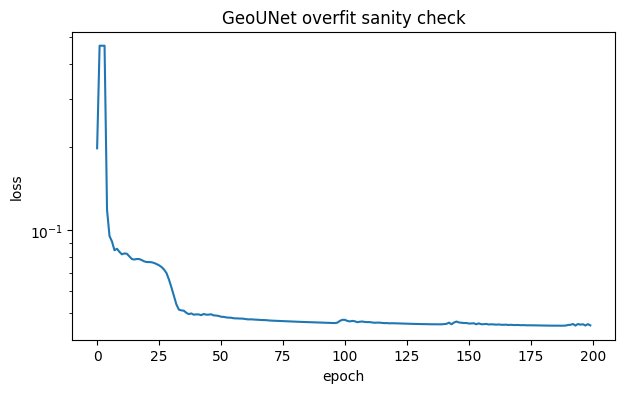

In [20]:
if CFG["overfit_debug_enabled"]:
    overfit_subset = Subset(ds_train, list(range(CFG["overfit_subset_size"])))
    overfit_loader = DataLoader(
        overfit_subset,
        batch_size=min(CFG["batch_size"], CFG["overfit_subset_size"]),
        shuffle=True, num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    overfit_model = USCTGeoUNet(
        embed_dim=CFG["embed_dim"], base_ch=CFG["unet_base_ch"],
        target_hw=(H, W), use_bilinear_up=CFG["unet_use_bilinear_up"],
        spreader_kernel=CFG["spreader_kernel"], spreader_layers=CFG["spreader_layers"],
        token_dim=CFG["token_dim"], branch_hidden=CFG["branch_hidden"],
        source_aggregation=CFG["source_aggregation"],
    ).to(device)

    overfit_optimizer = torch.optim.AdamW(
        overfit_model.parameters(), lr=CFG["overfit_lr"], weight_decay=0.0,
    )
    overfit_criterion = nn.MSELoss()
    overfit_scaler = torch.amp.GradScaler("cuda") if torch.cuda.is_available() else None

    overfit_history = []
    for epoch in range(1, CFG["overfit_epochs"] + 1):
        loss = train_one_epoch(
            overfit_model, overfit_loader, overfit_optimizer,
            overfit_criterion, device, scaler=overfit_scaler,
        )
        overfit_history.append(loss)
        if epoch == 1 or epoch % 20 == 0 or epoch == CFG["overfit_epochs"]:
            print(f"[overfit] epoch {epoch:03d} | loss={loss:.6f}")

    plt.figure(figsize=(7, 4))
    plt.plot(overfit_history)
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.yscale("log")
    plt.title("GeoUNet overfit sanity check")
    plt.show()

    del overfit_model, overfit_optimizer, overfit_scaler
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    print("overfit debug block is disabled")

## 8. Полное обучение

Тот же протокол, что у DeepONet/FNO/U-Net: AdamW + ReduceLROnPlateau + early
stopping по val MSE, AMP включён.

In [21]:
model = USCTGeoUNet(
    embed_dim=CFG["embed_dim"], base_ch=CFG["unet_base_ch"],
    target_hw=(H, W), use_bilinear_up=CFG["unet_use_bilinear_up"],
    spreader_kernel=CFG["spreader_kernel"], spreader_layers=CFG["spreader_layers"],
    token_dim=CFG["token_dim"], branch_hidden=CFG["branch_hidden"],
    source_aggregation=CFG["source_aggregation"],
).to(device)

print(f"GeoUNet params: {sum(p.numel() for p in model.parameters()):,}")

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min",
    factor=CFG["scheduler_factor"], patience=CFG["scheduler_patience"],
    min_lr=CFG["min_lr"],
)

use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda") if use_amp else None

RUN_DIR = Path("/workspace/reference_points") / CFG["run_name"]
RUN_DIR.mkdir(parents=True, exist_ok=True)

best_val = float("inf")
best_epoch = -1
best_ckpt_path = RUN_DIR / "geo_unet_best.pt"

train_history = []
val_history = []
lr_history = []
epochs_no_improve = 0

t0 = time.time()
for epoch in range(1, CFG["epochs"] + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, scaler=scaler)
    val_loss = eval_loss(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    train_history.append(train_loss)
    val_history.append(val_loss)
    lr_history.append(current_lr)

    print(f"epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | lr={current_lr:.6e}")

    if val_loss < best_val:
        best_val = val_loss
        best_epoch = epoch
        epochs_no_improve = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "stats": stats,
                "config": CFG,
                "best_epoch": best_epoch,
                "best_val": best_val,
            },
            best_ckpt_path,
        )
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= CFG["patience"]:
        print("early stopping")
        break
t1 = time.time()
print("training time sec:", t1 - t0)
print("best_epoch:", best_epoch)
print("best_val:", best_val)

GeoUNet params: 7,359,457
epoch 001 | train_loss=0.045642 | val_loss=0.041734 | lr=1.000000e-03
epoch 002 | train_loss=0.041675 | val_loss=0.040841 | lr=1.000000e-03
epoch 003 | train_loss=0.037243 | val_loss=0.032269 | lr=1.000000e-03
epoch 004 | train_loss=0.030719 | val_loss=0.028664 | lr=1.000000e-03
epoch 005 | train_loss=0.027886 | val_loss=0.026905 | lr=1.000000e-03
epoch 006 | train_loss=0.026343 | val_loss=0.026767 | lr=1.000000e-03
epoch 007 | train_loss=0.025302 | val_loss=0.026093 | lr=1.000000e-03
epoch 008 | train_loss=0.024728 | val_loss=0.024507 | lr=1.000000e-03
epoch 009 | train_loss=0.023955 | val_loss=0.023764 | lr=1.000000e-03
epoch 010 | train_loss=0.023218 | val_loss=0.023566 | lr=1.000000e-03
epoch 011 | train_loss=0.022505 | val_loss=0.022814 | lr=1.000000e-03
epoch 012 | train_loss=0.021799 | val_loss=0.021950 | lr=1.000000e-03
epoch 013 | train_loss=0.021253 | val_loss=0.022024 | lr=1.000000e-03
epoch 014 | train_loss=0.020714 | val_loss=0.021418 | lr=1.00000

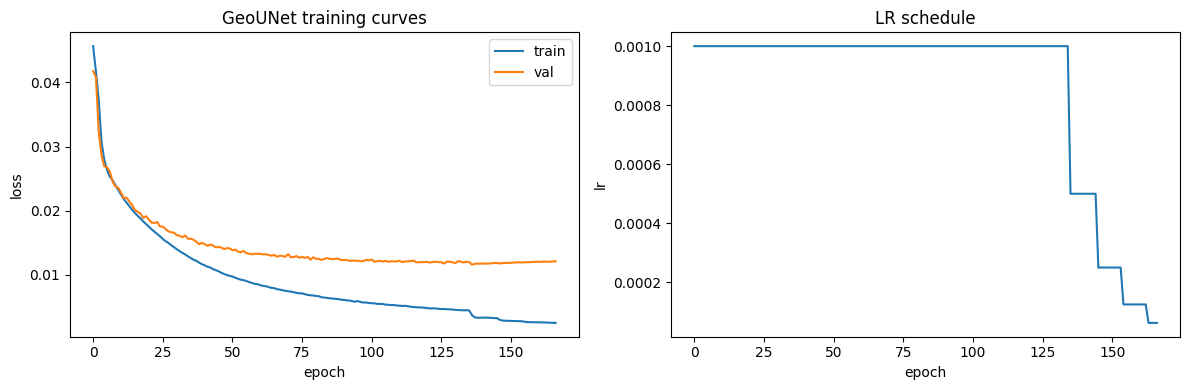

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(train_history, label="train")
ax[0].plot(val_history, label="val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[0].set_title("GeoUNet training curves"); ax[0].legend()

ax[1].plot(lr_history)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("lr")
ax[1].set_title("LR schedule")
plt.tight_layout()
plt.show()

## 9. Best checkpoint evaluation

In [23]:
best_ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(best_ckpt["model_state_dict"])
model.eval()

train_metrics = evaluate_dataset(model, ds_train, device, stats["c_min"], stats["c_max"])
val_metrics = evaluate_dataset(model, ds_val, device, stats["c_min"], stats["c_max"])
test_metrics = evaluate_dataset(model, ds_test, device, stats["c_min"], stats["c_max"])

train_summary = summarize_metrics(train_metrics)
val_summary = summarize_metrics(val_metrics)
test_summary = summarize_metrics(test_metrics)

print("TRAIN SUMMARY")
print(json.dumps(train_summary, ensure_ascii=False, indent=2))
print("\nVAL SUMMARY")
print(json.dumps(val_summary, ensure_ascii=False, indent=2))
print("\nTEST SUMMARY")
print(json.dumps(test_summary, ensure_ascii=False, indent=2))

TRAIN SUMMARY
{
  "mse_mean": 32.44637974739075,
  "mse_std": 11.373670670383888,
  "rmse_mean": 5.61269481705081,
  "rmse_std": 0.9716154864058001,
  "relative_l2_mean": 0.003762897276995523,
  "relative_l2_std": 0.0006559806957905245,
  "psnr_mean": 30.910281857371523,
  "psnr_std": 1.4964320921787293
}

VAL SUMMARY
{
  "mse_mean": 109.13085677528382,
  "mse_std": 90.92977055180357,
  "rmse_mean": 9.727838352918624,
  "rmse_std": 3.807888889563366,
  "relative_l2_mean": 0.006517259679967537,
  "relative_l2_std": 0.002543332266446768,
  "psnr_mean": 26.62905113555627,
  "psnr_std": 3.2788090616925794
}

TEST SUMMARY
{
  "mse_mean": 385.3311504936218,
  "mse_std": 222.39788049373186,
  "rmse_mean": 18.772560036182405,
  "rmse_std": 5.737781786142304,
  "relative_l2_mean": 0.012580186907434836,
  "relative_l2_std": 0.0038361356212914823,
  "psnr_mean": 20.73166741623837,
  "psnr_std": 2.8202850205043264
}


### 9.1 Geometry invariance на обученной модели

Тот же тест, что и на необученной модели — должно показать, что свойство сохраняется.

In [24]:
print("On TRAINED model:")
geom_invariance_test(model, ds_test, device, perm_kind="shift", k=4)
geom_invariance_test(model, ds_test, device, perm_kind="shift", k=37)
geom_invariance_test(model, ds_test, device, perm_kind="random")

On TRAINED model:
[geom invariance / shift, k=4]  max |y0 - y1| = 0.000e+00, relative = 0.000e+00
[geom invariance / shift, k=37]  max |y0 - y1| = 0.000e+00, relative = 0.000e+00
[geom invariance / random, k=4]  max |y0 - y1| = 0.000e+00, relative = 0.000e+00


(0.0, 0.0)

## 10. Визуализация на test

In [25]:
@torch.no_grad()
def show_prediction(model, dataset, idx, device, c_min, c_max):
    x, c, src_n, rcv_n, rcv_p, meta = dataset[idx]
    pred = model(
        x.unsqueeze(0).to(device),
        src_n.unsqueeze(0).to(device),
        rcv_n.unsqueeze(0).to(device),
        rcv_p.unsqueeze(0).to(device),
    )[0, 0].cpu().numpy()
    pred = np.clip(pred, -1.0, 1.0)
    target = c[0].numpy()
    pred_phys = denorm_c_from_minus1_1(pred, c_min, c_max)
    target_phys = denorm_c_from_minus1_1(target, c_min, c_max)
    err = np.abs(pred_phys - target_phys)

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    im0 = ax[0].imshow(target_phys, origin="lower")
    ax[0].set_title(f"target | idx={idx}"); plt.colorbar(im0, ax=ax[0])
    im1 = ax[1].imshow(pred_phys, origin="lower")
    ax[1].set_title("GeoUNet prediction"); plt.colorbar(im1, ax=ax[1])
    im2 = ax[2].imshow(err, origin="lower")
    ax[2].set_title("|pred - target|"); plt.colorbar(im2, ax=ax[2])
    plt.tight_layout()
    plt.show()
    print(meta["path"])

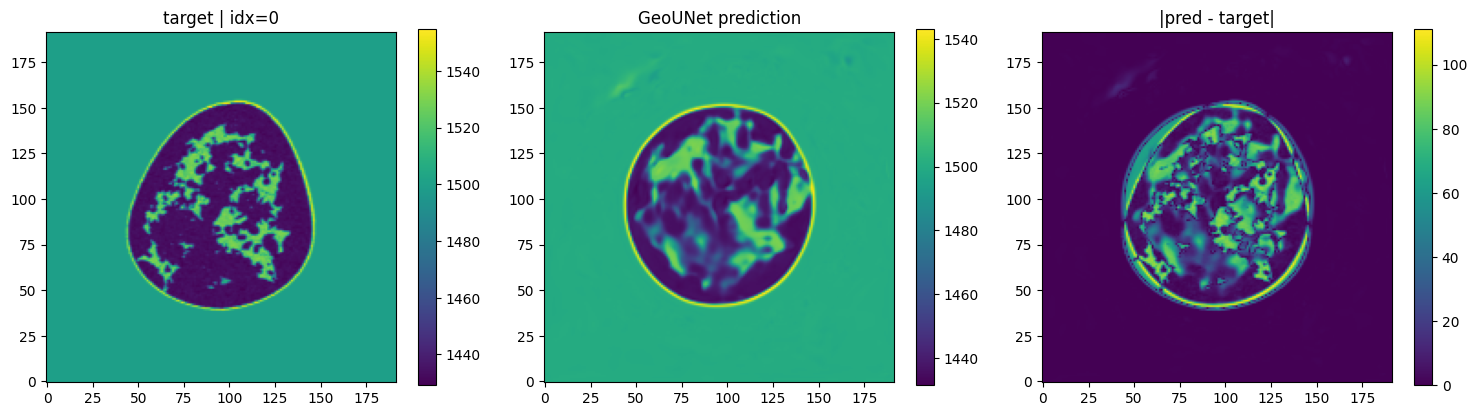

/workspace/usct_dataset_v2/test/sample_00000.npz


In [ ]:
for idx in [0, 1, 2]:
    show_prediction(model, ds_test, idx, device, stats["c_min"], stats["c_max"])

## 11. Save artifacts

In [ ]:
with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "config": CFG,
            "stats": stats,
            "S": int(S), "R": int(R),
            "H": int(H), "W": int(W),
            "dx": [float(v) for v in dx],
            "freq_hz": float(freq_hz),
            "best_epoch": int(best_epoch),
            "best_val": float(best_val),
            "num_params": int(sum(p.numel() for p in model.parameters())),
        },
        f, ensure_ascii=False, indent=2,
    )

with open(RUN_DIR / "train_summary.json", "w", encoding="utf-8") as f:
    json.dump(train_summary, f, ensure_ascii=False, indent=2)
with open(RUN_DIR / "val_summary.json", "w", encoding="utf-8") as f:
    json.dump(val_summary, f, ensure_ascii=False, indent=2)
with open(RUN_DIR / "test_summary.json", "w", encoding="utf-8") as f:
    json.dump(test_summary, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "train_metrics.json", "w", encoding="utf-8") as f:
    json.dump(train_metrics, f, ensure_ascii=False, indent=2)
with open(RUN_DIR / "val_metrics.json", "w", encoding="utf-8") as f:
    json.dump(val_metrics, f, ensure_ascii=False, indent=2)
with open(RUN_DIR / "test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, ensure_ascii=False, indent=2)

np.savez_compressed(
    RUN_DIR / "loss_history.npz",
    train_loss=np.array(train_history, dtype=np.float32),
    val_loss=np.array(val_history, dtype=np.float32),
    lr=np.array(lr_history, dtype=np.float32),
)
print("saved to:", RUN_DIR)